In [2]:
# First, make sure you have the 'unzip' utility available in your Colab environment
# This is usually pre-installed, but you can install it if needed:
# !apt-get install unzip

# Define the path to your zip file and the destination directory
zip_file_path = '/content/challenge_heart_sounds/classification-of-heart-sound-recordings-the-physionetcomputing-in-cardiology-challenge-2016-1.0.0.zip'
destination_directory = '/content/challenge-2016-1.0.0'

# Create the destination directory if it doesn't exist
!mkdir -p "{destination_directory}"

# Unzip the file into the destination directory
!unzip -q "{zip_file_path}" -d "{destination_directory}"

print(f"Successfully unzipped '{zip_file_path}' to '{destination_directory}'")
print("You can now inspect the contents using !ls -F /content/challenge-2016-1.0.0/")

Successfully unzipped '/content/challenge_heart_sounds/classification-of-heart-sound-recordings-the-physionetcomputing-in-cardiology-challenge-2016-1.0.0.zip' to '/content/challenge-2016-1.0.0'
You can now inspect the contents using !ls -F /content/challenge-2016-1.0.0/


Loaded 3541 labeled recordings
label
Normal      2725
Abnormal     816
Name: count, dtype: int64


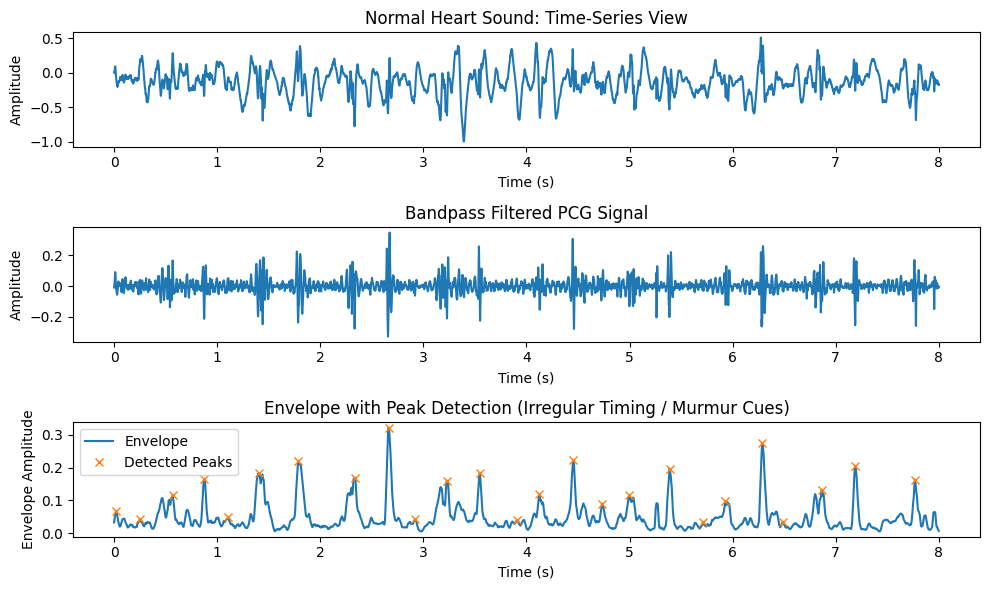

Detected peak intervals (seconds):
[0.2275 0.318  0.3095 0.228  0.2965 0.3865 0.5505 0.324  0.2585 0.307
 0.3185 0.363  0.2145 0.329  0.2805 0.2625 0.393  0.322  0.2185 0.36  ]


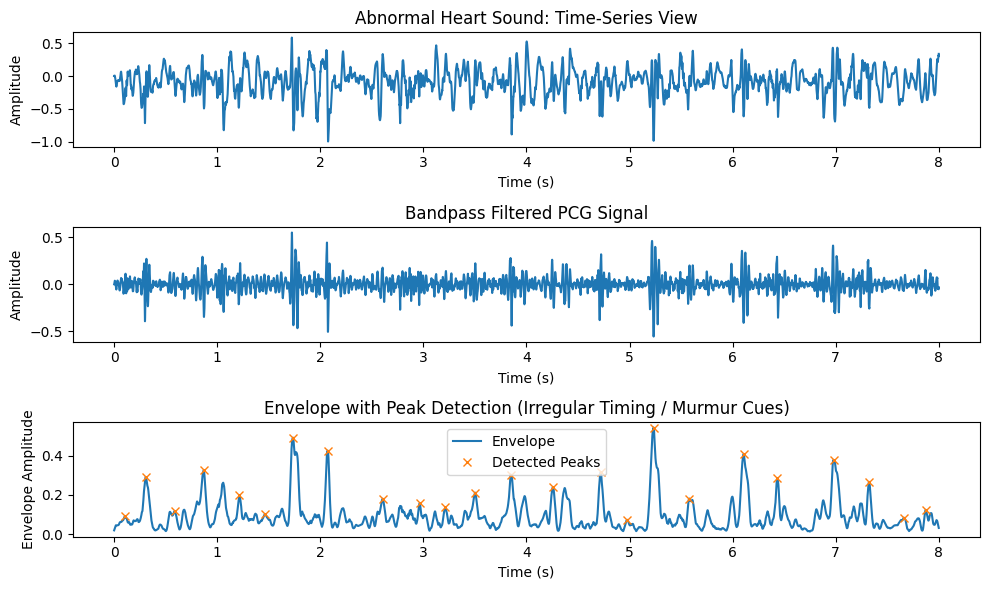

Detected peak intervals (seconds):
[0.2035 0.282  0.2815 0.346  0.246  0.2745 0.3365 0.5335 0.358  0.25
 0.2885 0.345  0.41   0.4625 0.26   0.2535 0.348  0.5255 0.3265 0.5455]


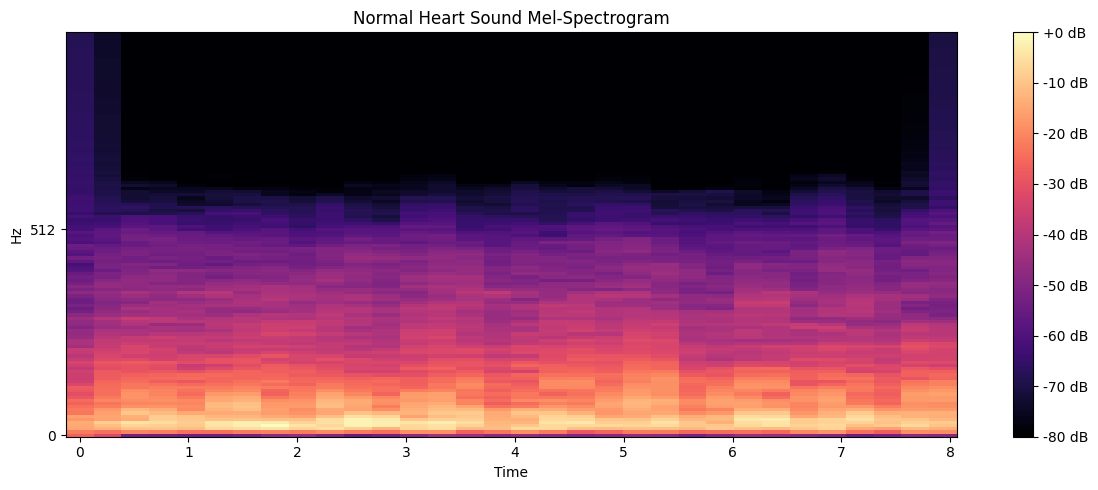

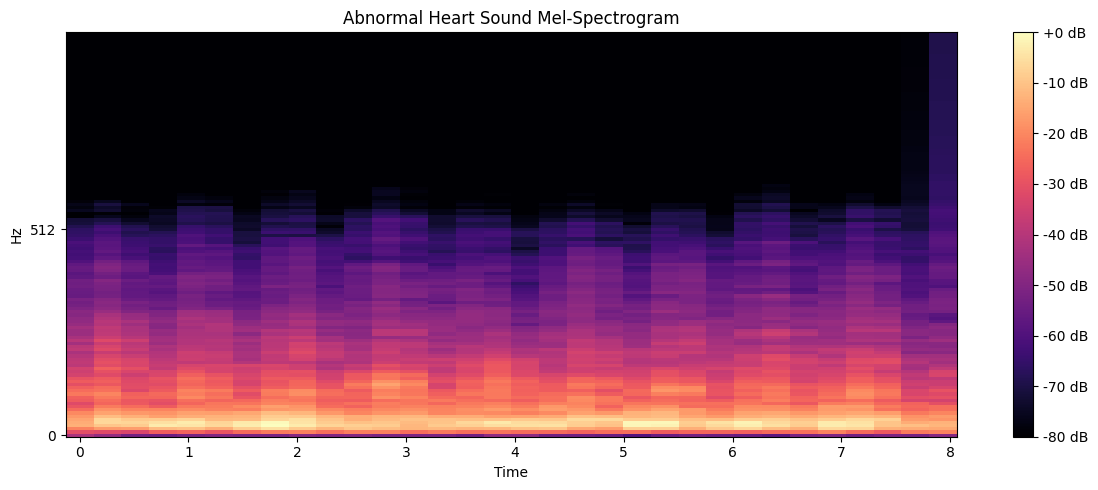

Extracting features...
Feature matrix shape: (3541, 88)
Label shape: (3541,)


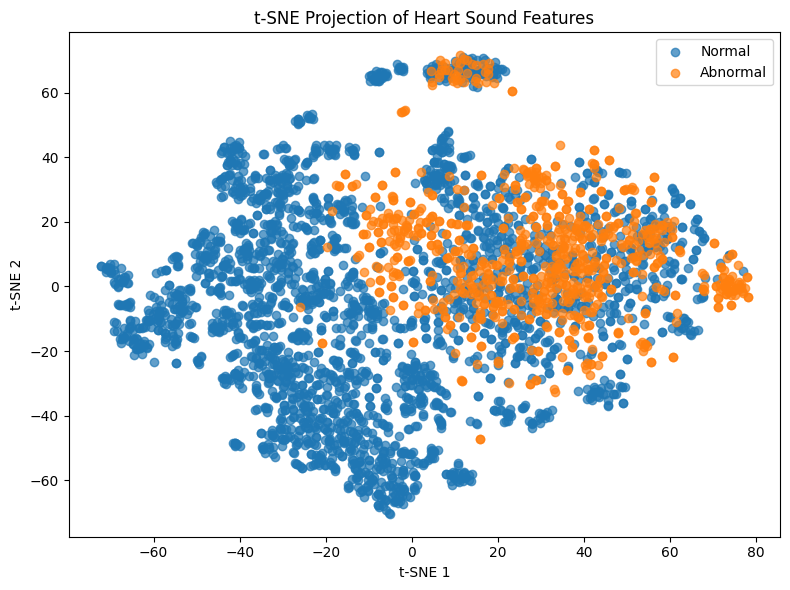

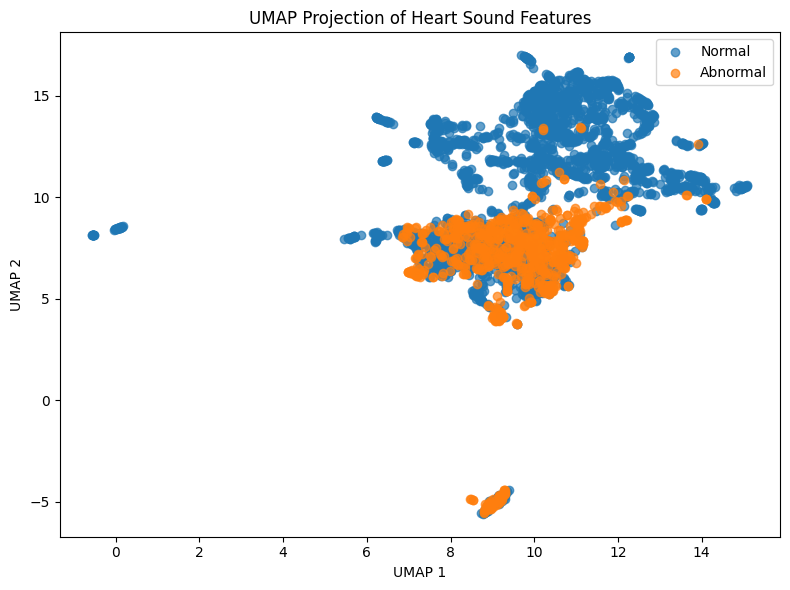


Classification Report:
              precision    recall  f1-score   support

      Normal       0.93      0.97      0.95       546
    Abnormal       0.89      0.75      0.82       163

    accuracy                           0.92       709
   macro avg       0.91      0.86      0.88       709
weighted avg       0.92      0.92      0.92       709



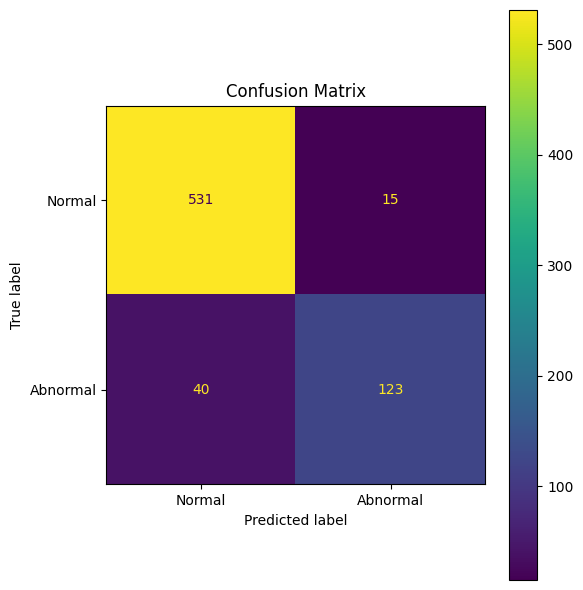

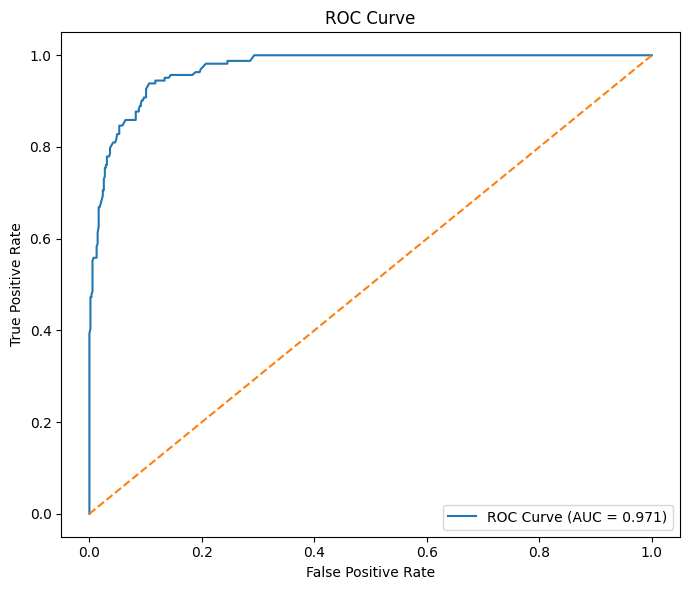

Number of feature names: 88
Number of model features: 88
Generating SHAP summary plot...


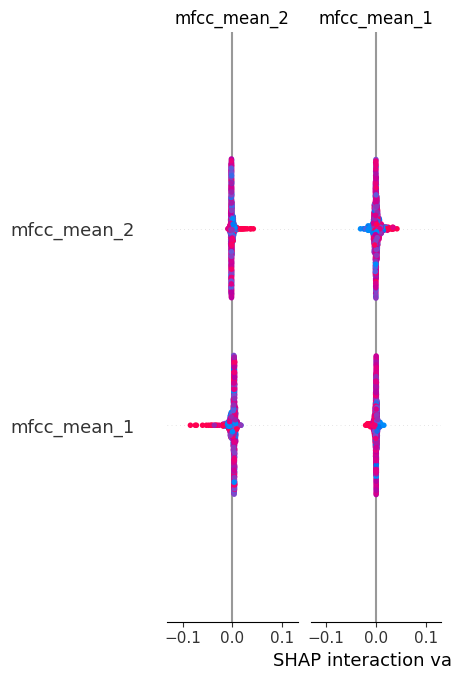

Generating SHAP bar plot...


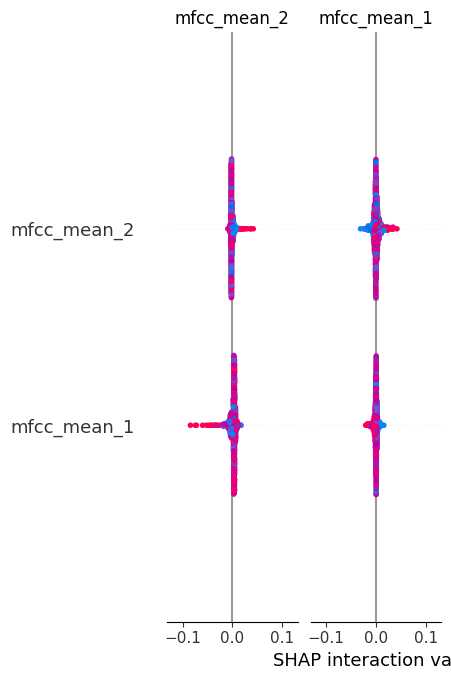

Explaining test sample index 0


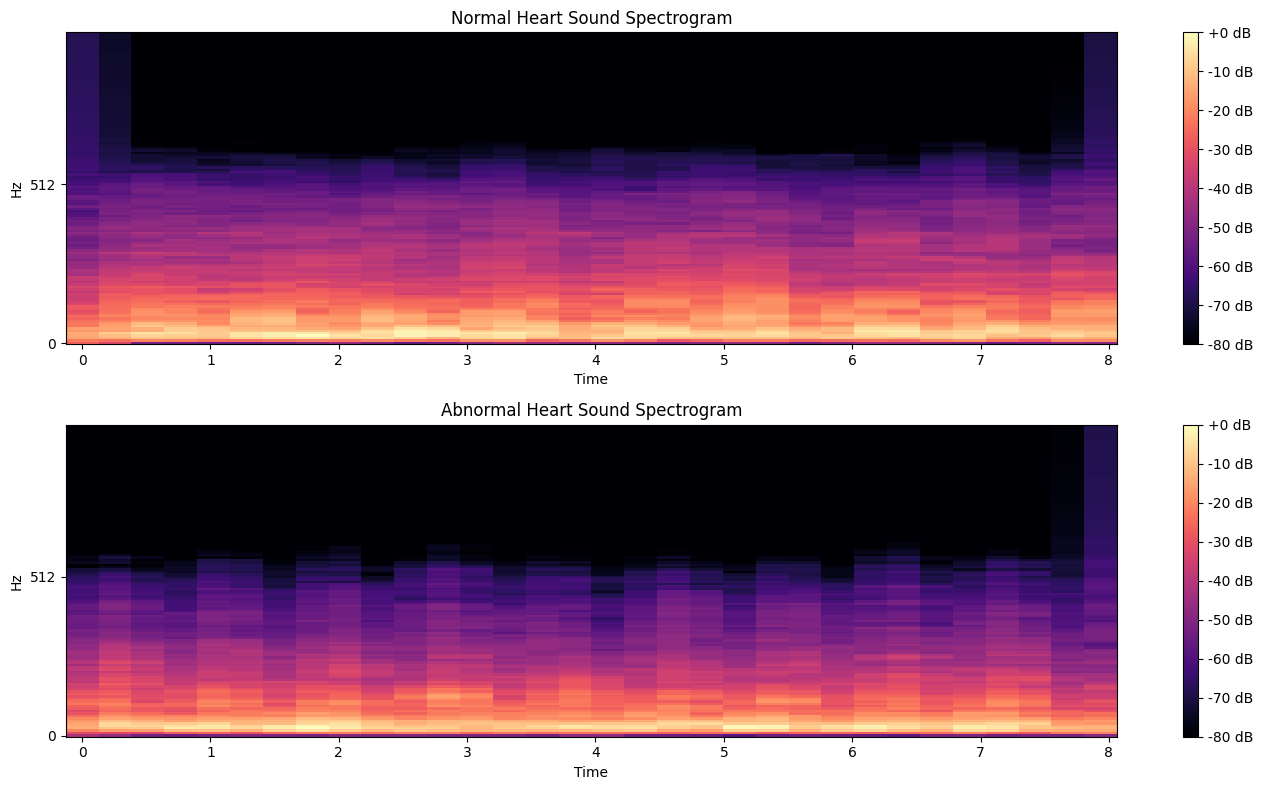

In [3]:
# ============================================================
# PhysioNet/CinC 2016 Heart Sound Visualization + ML Pipeline
# ============================================================

# -----------------------------
# 1. Imports
# -----------------------------
import os
import glob
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.io import wavfile
from scipy.signal import butter, filtfilt, hilbert, find_peaks

import librosa
import librosa.display

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.manifold import TSNE
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc,
    classification_report
)
from sklearn.ensemble import RandomForestClassifier

import umap.umap_ as umap

import shap

# -----------------------------
# 2. Configuration
# -----------------------------
# CHANGE THIS to your dataset root folder
DATA_ROOT = r"/content/challenge-2016-1.0.0/classification-of-heart-sound-recordings-the-physionet-computing-in-cardiology-challenge-2016-1.0.0"

# Example expected structure:
# DATA_ROOT/
#   training-a/
#       REFERENCE.csv
#       a0001.wav
#       ...
#   training-b/
#       REFERENCE.csv
#       ...
#   ...
#   validation/
#       REFERENCE.csv
#       ...

TARGET_SR = 2000   # resample for consistency
RANDOM_STATE = 42

# -----------------------------
# 3. Helper functions
# -----------------------------
def normalize_label(label):
    """
    Normalize PhysioNet labels to 0/1:
    0 = normal
    1 = abnormal
    """
    label_str = str(label).strip().lower()

    if label_str in ["1", "abnormal", "abnormality"]:
        return 1
    elif label_str in ["-1", "0", "normal"]:
        return 0
    else:
        # ignore uncertain/unrecognized labels if present
        return None


def collect_reference_files(root_dir):
    """
    Find all REFERENCE.csv files recursively.
    """
    return glob.glob(os.path.join(root_dir, "**", "REFERENCE.csv"), recursive=True)


def load_metadata(root_dir):
    """
    Build a dataframe of filepaths and labels from all REFERENCE.csv files.
    """
    records = []
    ref_files = collect_reference_files(root_dir)

    for ref_file in ref_files:
        folder = os.path.dirname(ref_file)
        ref_df = pd.read_csv(ref_file, header=None)

        # Usually columns: recording_id, label
        if ref_df.shape[1] < 2:
            continue

        for _, row in ref_df.iterrows():
            rec_id = str(row[0]).strip()
            raw_label = row[1]
            label = normalize_label(raw_label)

            if label is None:
                continue

            wav_path = os.path.join(folder, f"{rec_id}.wav")
            if os.path.exists(wav_path):
                records.append({
                    "recording_id": rec_id,
                    "filepath": wav_path,
                    "label": label
                })

    return pd.DataFrame(records)


def load_audio(filepath, target_sr=TARGET_SR):
    """
    Load WAV file and resample if needed.
    Returns audio float32 in range approx [-1, 1], and sample rate.
    """
    sr, audio = wavfile.read(filepath)

    # Convert to float
    if audio.dtype != np.float32:
        audio = audio.astype(np.float32)

    # Handle integer PCM scaling
    if np.max(np.abs(audio)) > 1:
        audio /= np.max(np.abs(audio))

    # Convert stereo to mono if needed
    if audio.ndim > 1:
        audio = np.mean(audio, axis=1)

    # Resample
    if sr != target_sr:
        audio = librosa.resample(audio, orig_sr=sr, target_sr=target_sr)
        sr = target_sr

    return audio, sr


def bandpass_filter(signal, sr, low=20, high=400, order=4):
    """
    Simple bandpass filter suitable for PCG signals.
    """
    nyq = 0.5 * sr
    lowcut = low / nyq
    highcut = high / nyq
    b, a = butter(order, [lowcut, highcut], btype="band")
    return filtfilt(b, a, signal)


def get_envelope(signal):
    """
    Compute amplitude envelope using Hilbert transform.
    """
    analytic_signal = hilbert(signal)
    envelope = np.abs(analytic_signal)
    return envelope


def estimate_beat_peaks(envelope, sr):
    """
    Rough peak detection on the envelope to suggest heart sound events.
    """
    distance = int(0.2 * sr)  # minimum spacing between peaks
    prominence = np.percentile(envelope, 75) * 0.2
    peaks, _ = find_peaks(envelope, distance=distance, prominence=prominence)
    return peaks


def extract_features(filepath):
    """
    Extract a compact feature vector for classical ML + t-SNE/UMAP.
    """
    y, sr = load_audio(filepath)

    # Pre-filter
    y_filt = bandpass_filter(y, sr)

    # MFCCs
    mfcc = librosa.feature.mfcc(y=y_filt, sr=sr, n_mfcc=13)
    mfcc_delta = librosa.feature.delta(mfcc)
    mfcc_delta2 = librosa.feature.delta(mfcc, order=2)

    # Spectral features
    spec_centroid = librosa.feature.spectral_centroid(y=y_filt, sr=sr)
    spec_bandwidth = librosa.feature.spectral_bandwidth(y=y_filt, sr=sr)
    spec_rolloff = librosa.feature.spectral_rolloff(y=y_filt, sr=sr)
    zcr = librosa.feature.zero_crossing_rate(y_filt)
    rms = librosa.feature.rms(y=y_filt)

    # Chroma is not always ideal for heart sounds, so omitted
    feature_vector = np.hstack([
        mfcc.mean(axis=1), mfcc.std(axis=1),
        mfcc_delta.mean(axis=1), mfcc_delta.std(axis=1),
        mfcc_delta2.mean(axis=1), mfcc_delta2.std(axis=1),
        spec_centroid.mean(axis=1), spec_centroid.std(axis=1),
        spec_bandwidth.mean(axis=1), spec_bandwidth.std(axis=1),
        spec_rolloff.mean(axis=1), spec_rolloff.std(axis=1),
        zcr.mean(axis=1), zcr.std(axis=1),
        rms.mean(axis=1), rms.std(axis=1)
    ])

    return feature_vector


# -----------------------------
# 4. Load dataset metadata
# -----------------------------
df = load_metadata(DATA_ROOT)
print(f"Loaded {len(df)} labeled recordings")
print(df["label"].value_counts().rename({0: "Normal", 1: "Abnormal"}))

# -----------------------------
# 5. A. Time-Series Visualization
# -----------------------------
def plot_time_series_with_murmur_cues(filepath, title=None):
    """
    Plot raw PCG waveform + filtered waveform + envelope + detected peaks.
    Useful for visually inspecting murmurs or irregular timing.
    """
    y, sr = load_audio(filepath)
    y_filt = bandpass_filter(y, sr)
    envelope = get_envelope(y_filt)

    # Smooth envelope a bit
    win = int(0.03 * sr)
    win = max(win, 1)
    kernel = np.ones(win) / win
    env_smooth = np.convolve(envelope, kernel, mode="same")

    peaks = estimate_beat_peaks(env_smooth, sr)
    times = np.arange(len(y)) / sr
    peak_times = peaks / sr

    plt.figure(figsize=(10, 6))

    plt.subplot(3, 1, 1)
    plt.plot(times, y)
    plt.title(title if title else f"Raw Heart Sound Waveform\n{os.path.basename(filepath)}")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")

    plt.subplot(3, 1, 2)
    plt.plot(times, y_filt)
    plt.title("Bandpass Filtered PCG Signal")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")

    plt.subplot(3, 1, 3)
    plt.plot(times, env_smooth, label="Envelope")
    plt.plot(peak_times, env_smooth[peaks], "x", label="Detected Peaks")
    plt.title("Envelope with Peak Detection (Irregular Timing / Murmur Cues)")
    plt.xlabel("Time (s)")
    plt.ylabel("Envelope Amplitude")
    plt.legend()

    plt.tight_layout()
    plt.show()

    # Optional interval printout
    if len(peak_times) > 1:
        intervals = np.diff(peak_times)
        print("Detected peak intervals (seconds):")
        print(intervals[:20])


# Example: one normal and one abnormal recording
normal_example = df[df["label"] == 0]["filepath"].iloc[0]
abnormal_example = df[df["label"] == 1]["filepath"].iloc[0]

plot_time_series_with_murmur_cues(normal_example, title="Normal Heart Sound: Time-Series View")
plot_time_series_with_murmur_cues(abnormal_example, title="Abnormal Heart Sound: Time-Series View")


# -----------------------------
# 6. B. Spectrogram Visualization
# -----------------------------
def plot_mel_spectrogram(filepath, title=None):
    y, sr = load_audio(filepath)
    y_filt = bandpass_filter(y, sr)

    mel_spec = librosa.feature.melspectrogram(y=y_filt, sr=sr, n_mels=128, fmax=800)
    mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)

    plt.figure(figsize=(12, 5))
    librosa.display.specshow(mel_spec_db, sr=sr, x_axis="time", y_axis="mel")
    plt.colorbar(format="%+2.0f dB")
    plt.title(title if title else f"Mel Spectrogram\n{os.path.basename(filepath)}")
    plt.tight_layout()
    plt.show()


plot_mel_spectrogram(normal_example, title="Normal Heart Sound Mel-Spectrogram")
plot_mel_spectrogram(abnormal_example, title="Abnormal Heart Sound Mel-Spectrogram")


# -----------------------------
# 7. Feature Extraction for ML + Dimensionality Reduction
# -----------------------------
print("Extracting features...")
X = []
y = []

for _, row in df.iterrows():
    try:
        feat = extract_features(row["filepath"])
        X.append(feat)
        y.append(row["label"])
    except Exception as e:
        print(f"Skipping {row['filepath']} due to error: {e}")

X = np.array(X)
y = np.array(y)

print("Feature matrix shape:", X.shape)
print("Label shape:", y.shape)

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# -----------------------------
# 8. C. Dimensionality Reduction (t-SNE / UMAP)
# -----------------------------
def plot_tsne(X_scaled, y):
    tsne = TSNE(
        n_components=2,
        perplexity=30,
        learning_rate="auto",
        init="pca",
        random_state=RANDOM_STATE
    )
    X_tsne = tsne.fit_transform(X_scaled)

    plt.figure(figsize=(8, 6))
    plt.scatter(X_tsne[y == 0, 0], X_tsne[y == 0, 1], alpha=0.7, label="Normal")
    plt.scatter(X_tsne[y == 1, 0], X_tsne[y == 1, 1], alpha=0.7, label="Abnormal")
    plt.title("t-SNE Projection of Heart Sound Features")
    plt.xlabel("t-SNE 1")
    plt.ylabel("t-SNE 2")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_umap(X_scaled, y):
    reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=RANDOM_STATE)
    X_umap = reducer.fit_transform(X_scaled)

    plt.figure(figsize=(8, 6))
    plt.scatter(X_umap[y == 0, 0], X_umap[y == 0, 1], alpha=0.7, label="Normal")
    plt.scatter(X_umap[y == 1, 0], X_umap[y == 1, 1], alpha=0.7, label="Abnormal")
    plt.title("UMAP Projection of Heart Sound Features")
    plt.xlabel("UMAP 1")
    plt.ylabel("UMAP 2")
    plt.legend()
    plt.tight_layout()
    plt.show()


plot_tsne(X_scaled, y)
plot_umap(X_scaled, y)


# -----------------------------
# 9. Train/Test Split + Model
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

clf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)[:, 1]

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Normal", "Abnormal"]))


# -----------------------------
# 10. D.i. Confusion Matrix
# -----------------------------
def plot_confusion(y_test, y_pred):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal", "Abnormal"])

    fig, ax = plt.subplots(figsize=(6, 6))
    disp.plot(ax=ax, values_format="d")
    plt.title("Confusion Matrix")
    plt.tight_layout()
    plt.show()


plot_confusion(y_test, y_pred)


# -----------------------------
# 11. D.ii. ROC Curve
# -----------------------------
def plot_roc(y_test, y_proba):
    fpr, tpr, thresholds = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(7, 6))
    plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.3f})")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.show()


plot_roc(y_test, y_proba)


# -----------------------------
# 12. E. Explainability with SHAP
# -----------------------------
# Create feature names matching extract_features()
feature_names = []

# 13 MFCC means/stds
for prefix in ["mfcc_mean", "mfcc_std", "delta_mean", "delta_std", "delta2_mean", "delta2_std"]:
    for i in range(13):
        feature_names.append(f"{prefix}_{i+1}")

# spectral summary features
feature_names += [
    "spec_centroid_mean", "spec_centroid_std",
    "spec_bandwidth_mean", "spec_bandwidth_std",
    "spec_rolloff_mean", "spec_rolloff_std",
    "zcr_mean", "zcr_std",
    "rms_mean", "rms_std"
]

print("Number of feature names:", len(feature_names))
print("Number of model features:", X_train.shape[1])

# SHAP explainer for tree-based model
explainer = shap.TreeExplainer(clf)
shap_values = explainer.shap_values(X_test)

# For binary classification, shap_values may be a list of 2 arrays
# Usually class 1 (abnormal) is shap_values[1]
if isinstance(shap_values, list) and len(shap_values) == 2:
    shap_values_for_plot = shap_values[1]
else:
    shap_values_for_plot = shap_values

# SHAP summary plot
print("Generating SHAP summary plot...")
shap.summary_plot(
    shap_values_for_plot,
    X_test,
    feature_names=feature_names,
    show=True
)

# Optional SHAP bar plot
print("Generating SHAP bar plot...")
shap.summary_plot(
    shap_values_for_plot,
    X_test,
    feature_names=feature_names,
    plot_type="bar",
    show=True
)

# -----------------------------
# 13. Optional: SHAP force plot for one test sample
# -----------------------------
sample_idx = 0
print(f"Explaining test sample index {sample_idx}")

# In notebooks, this works best:
# shap.initjs()
# shap.force_plot(
#     explainer.expected_value[1] if isinstance(explainer.expected_value, (list, np.ndarray)) else explainer.expected_value,
#     shap_values_for_plot[sample_idx],
#     X_test[sample_idx],
#     feature_names=feature_names
# )

# -----------------------------
# 14. Optional: Compare one normal vs one abnormal spectrogram
# -----------------------------
def compare_two_spectrograms(file1, file2, title1="Sample 1", title2="Sample 2"):
    y1, sr1 = load_audio(file1)
    y2, sr2 = load_audio(file2)

    y1 = bandpass_filter(y1, sr1)
    y2 = bandpass_filter(y2, sr2)

    mel1 = librosa.feature.melspectrogram(y=y1, sr=sr1, n_mels=128, fmax=800)
    mel2 = librosa.feature.melspectrogram(y=y2, sr=sr2, n_mels=128, fmax=800)

    mel1_db = librosa.power_to_db(mel1, ref=np.max)
    mel2_db = librosa.power_to_db(mel2, ref=np.max)

    plt.figure(figsize=(14, 8))

    plt.subplot(2, 1, 1)
    librosa.display.specshow(mel1_db, sr=sr1, x_axis="time", y_axis="mel")
    plt.colorbar(format="%+2.0f dB")
    plt.title(title1)

    plt.subplot(2, 1, 2)
    librosa.display.specshow(mel2_db, sr=sr2, x_axis="time", y_axis="mel")
    plt.colorbar(format="%+2.0f dB")
    plt.title(title2)

    plt.tight_layout()
    plt.show()


compare_two_spectrograms(
    normal_example,
    abnormal_example,
    title1="Normal Heart Sound Spectrogram",
    title2="Abnormal Heart Sound Spectrogram"
)

In [5]:
# ============================================================
# Machine Learning Pipeline for Heart Sound Classification
# Models:
# Logistic Regression, Random Forest, Decision Tree,
# Naive Bayes, KNN, SVM, LightGBM, XGBoost, CatBoost
# ============================================================

# -----------------------------
# 1. Install packages if needed
# -----------------------------
!pip install lightgbm xgboost catboost

# -----------------------------
# 2. Imports
# -----------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier


# ============================================================
# 3. Assumption:
# You already created X and y from your heart sound features
# ============================================================

# X = feature matrix from MFCCs, spectral features, RMS, etc.
# y = labels where 0 = Normal, 1 = Abnormal

# Example:
# X.shape -> (number_of_recordings, number_of_features)
# y.shape -> (number_of_recordings,)


# -----------------------------
# 4. Train/Test Split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)


# -----------------------------
# 5. Standardize Features
# -----------------------------
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# -----------------------------
# 6. Define Models
# -----------------------------
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        class_weight="balanced",
        random_state=42
    ),

    "Naive Bayes": GaussianNB(),

    "K-Nearest Neighbor": KNeighborsClassifier(
        n_neighbors=5
    ),

    "Support Vector Machine": SVC(
        kernel="rbf",
        probability=True,
        class_weight="balanced",
        random_state=42
    ),

    "LightGBM": LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        class_weight="balanced",
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        eval_metric="logloss",
        random_state=42
    ),

    "CatBoost": CatBoostClassifier(
        iterations=300,
        learning_rate=0.05,
        depth=6,
        verbose=0,
        random_state=42
    )
}


# -----------------------------
# 7. Metric Function
# -----------------------------
def calculate_metrics(y_true, y_pred, y_proba):
    """
    Calculates binary classification metrics:
    Accuracy, Precision, Recall, F1, Sensitivity, Specificity, ROC-AUC
    """

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)

    # Sensitivity is the same as recall for the positive class
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0

    # Specificity is true negative rate
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

    f1 = f1_score(y_true, y_pred, zero_division=0)

    try:
        roc_auc = roc_auc_score(y_true, y_proba)
    except:
        roc_auc = np.nan

    return {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "Sensitivity": sensitivity,
        "Specificity": specificity,
        "F1 Score": f1,
        "ROC-AUC": roc_auc,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    }


# -----------------------------
# 8. Train and Evaluate Models
# -----------------------------
results = []

for model_name, model in models.items():

    print(f"\nTraining {model_name}...")

    model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_test_scaled)

    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test_scaled)[:, 1]
    else:
        y_proba = model.decision_function(X_test_scaled)

    metrics = calculate_metrics(y_test, y_pred, y_proba)
    metrics["Model"] = model_name

    results.append(metrics)

    print(f"\nClassification Report for {model_name}:")
    print(classification_report(
        y_test,
        y_pred,
        target_names=["Normal", "Abnormal"]
    ))


# -----------------------------
# 9. Create Results DataFrame
# -----------------------------
results_df = pd.DataFrame(results)

results_df = results_df[
    [
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "Sensitivity",
        "Specificity",
        "F1 Score",
        "ROC-AUC",
        "TN",
        "FP",
        "FN",
        "TP"
    ]
]

# Convert metrics to percentages
metric_cols = [
    "Accuracy",
    "Precision",
    "Recall",
    "Sensitivity",
    "Specificity",
    "F1 Score",
    "ROC-AUC"
]

results_df[metric_cols] = results_df[metric_cols] * 100

results_df = results_df.sort_values(by="F1 Score", ascending=False)

print("\nFinal Model Performance Summary:")
display(results_df)


# -----------------------------
# 10. Save Results
# -----------------------------
results_df.to_csv("heart_sound_model_performance.csv", index=False)

print("Results saved as heart_sound_model_performance.csv")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 6.4 MB/s eta 0:00:00

Training Logistic Regression...

Classification Report for Logistic Regression:
              precision    recall  f1-score   support

      Normal       0.95      0.82      0.88       546
    Abnormal       0.59      0.84      0.69       163

    accuracy                           0.83       709
   macro avg       0.77      0.83      0.79       709
weighted avg       0.86      0.83      0.84       709


Training Random Forest...

Classification Report for Random Forest:
              precision    recall  f1-score   support

      Normal       0.92      0.97      0.95       546
    Abnormal       0.89      0.73      0.80       163

    accuracy                           0.92       709
   macro avg       0.91      0.85      0.87       709
weighted avg       0.92      0.92      0.91       709


Training Decision Tree...

Classification Report for Decision Tree:
              precision    recall  f1-score   sup

,Model,Accuracy,Precision,Recall,Sensitivity,Specificity,F1 Score,ROC-AUC,TN,FP,FN,TP
6,LightGBM,91.960508,81.547619,84.049080,84.049080,94.322344,82.779456,97.166228,515,31,26,137
8,CatBoost,91.537377,82.802548,79.754601,79.754601,95.054945,81.250000,97.034765,519,27,33,130
1,Random Forest,91.678420,88.805970,73.006135,73.006135,97.252747,80.134680,96.737005,531,15,44,119
7,XGBoost,91.255289,84.827586,75.460123,75.460123,95.970696,79.870130,96.828019,524,22,40,123
5,Support Vector Machine,86.600846,65.178571,89.570552,89.570552,85.714286,75.452196,94.848199,468,78,17,146
2,Decision Tree,88.011283,74.375000,73.006135,73.006135,92.490842,73.684211,82.748489,505,41,44,119
4,K-Nearest Neighbor,86.036671,67.021277,77.300613,77.300613,88.644689,71.794872,92.546462,484,62,37,126
0,Logistic Regression,82.792666,58.798283,84.049080,84.049080,82.417582,69.191919,91.205420,450,96,26,137
3,Naive Bayes,80.253879,54.978355,77.914110,77.914110,80.952381,64.467005,86.673858,442,104,36,127


Results saved as heart_sound_model_performance.csv


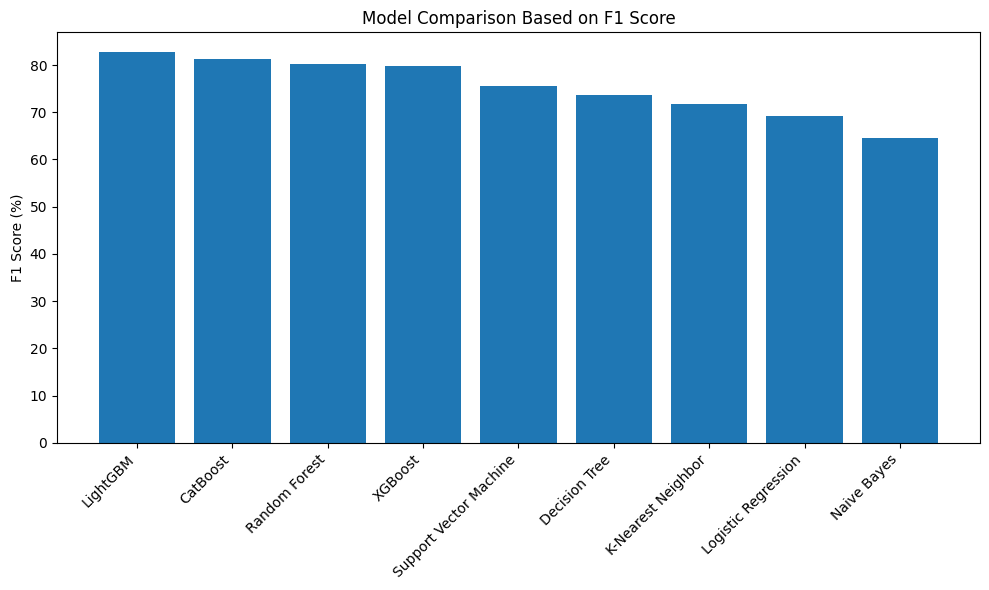

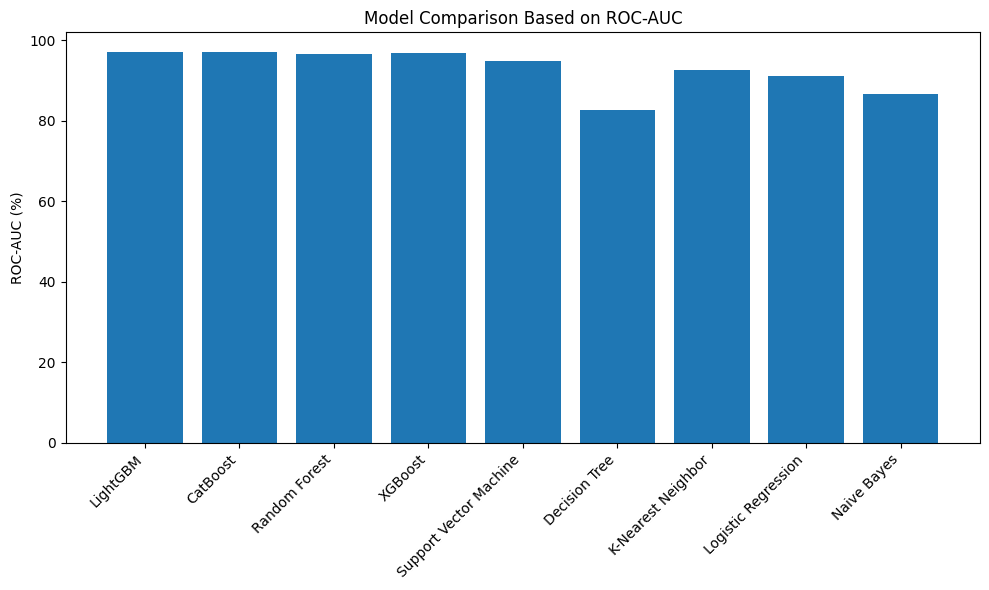

In [11]:
# ============================================================
# Plot Model Performance Comparison
# ============================================================

plt.figure(figsize=(10, 6))
plt.bar(results_df["Model"], results_df["F1 Score"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("F1 Score (%)")
plt.title("Model Comparison Based on F1 Score")
plt.tight_layout()
plt.show()


plt.figure(figsize=(10, 6))
plt.bar(results_df["Model"], results_df["ROC-AUC"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("ROC-AUC (%)")
plt.title("Model Comparison Based on ROC-AUC")
plt.tight_layout()
plt.show()


Plotting Confusion Matrix for Logistic Regression...


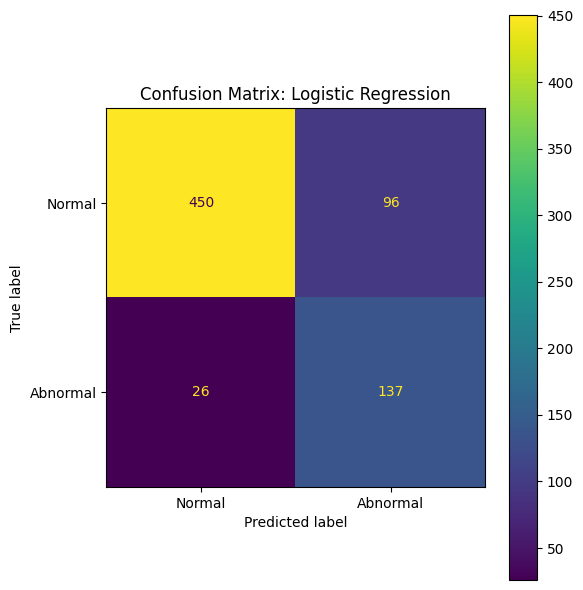


Plotting Confusion Matrix for Random Forest...


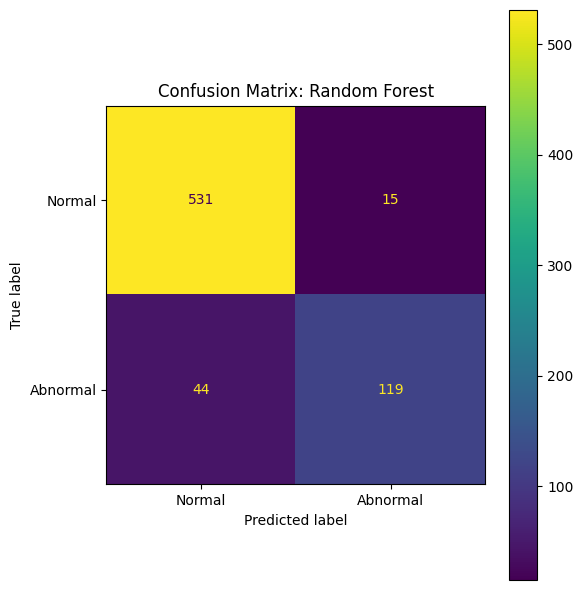


Plotting Confusion Matrix for Decision Tree...


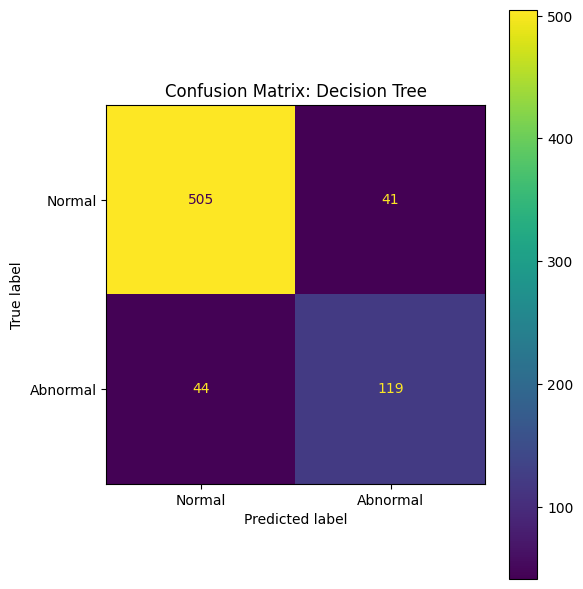


Plotting Confusion Matrix for Naive Bayes...


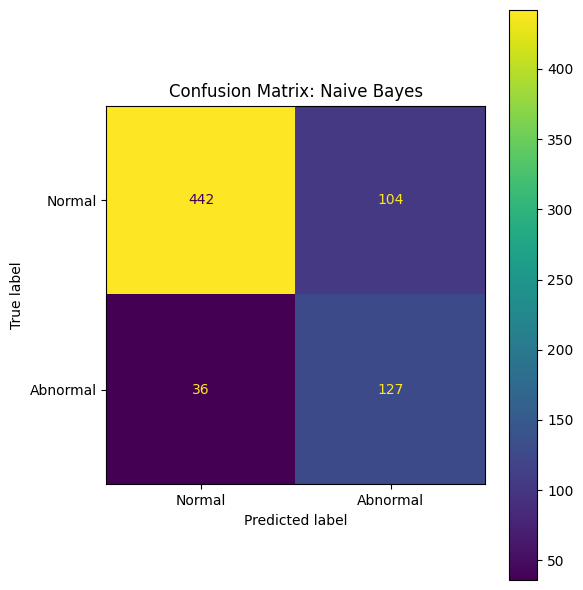


Plotting Confusion Matrix for K-Nearest Neighbor...


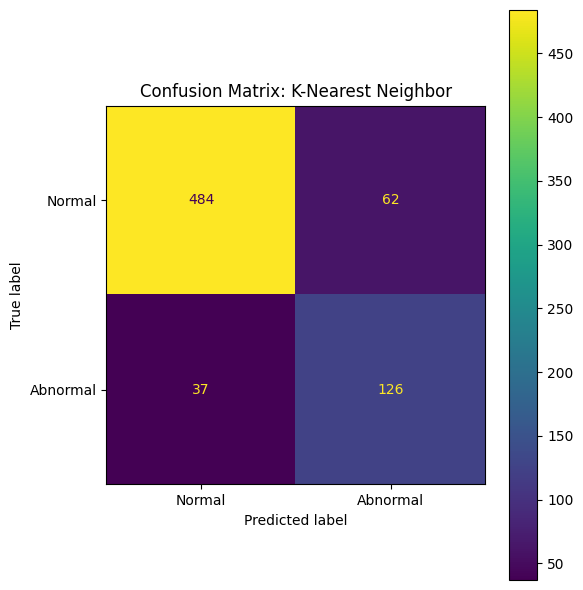


Plotting Confusion Matrix for Support Vector Machine...


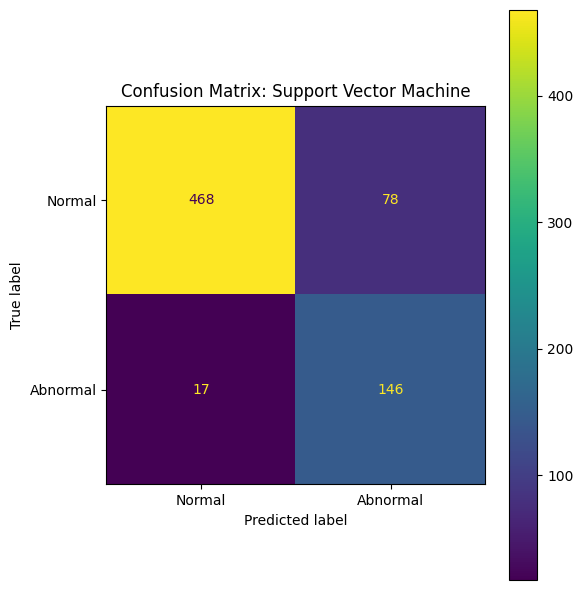


Plotting Confusion Matrix for LightGBM...


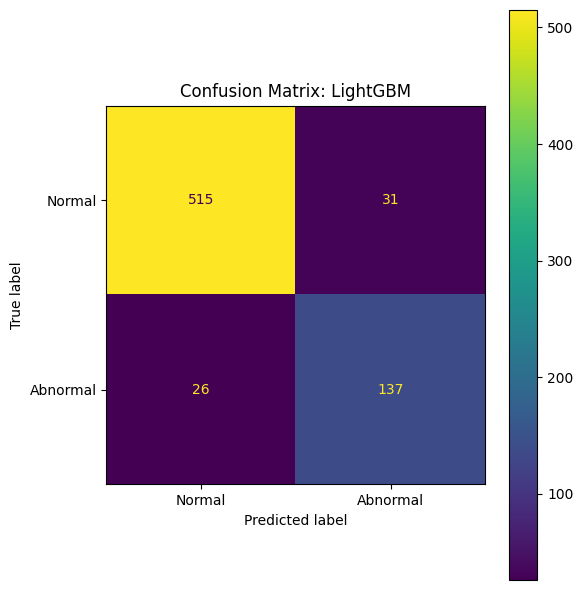


Plotting Confusion Matrix for XGBoost...


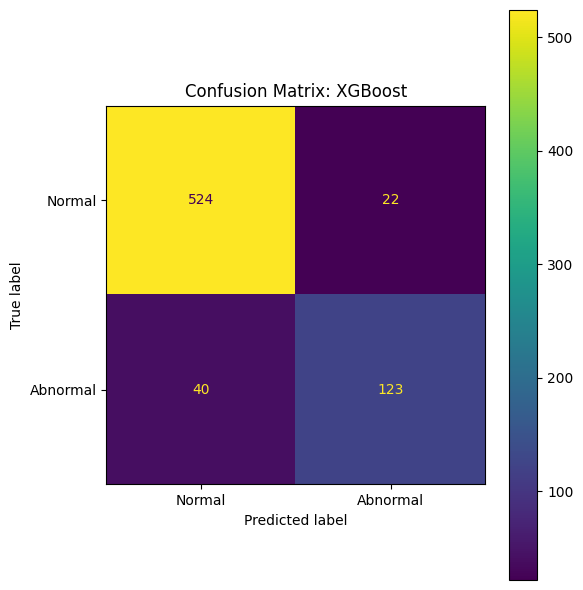


Plotting Confusion Matrix for CatBoost...


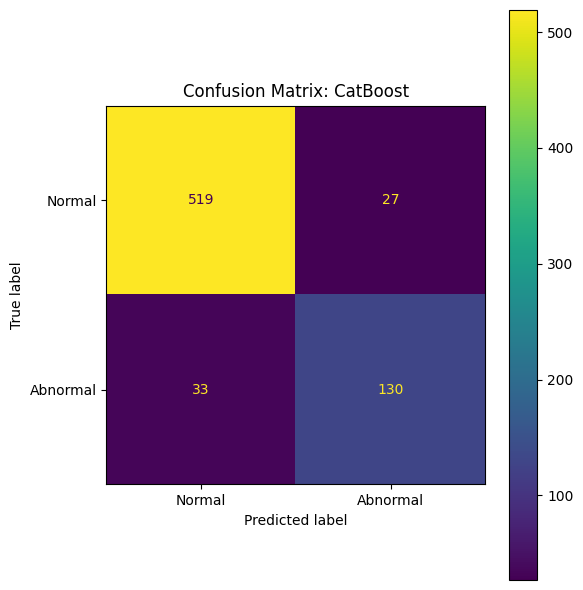

In [8]:
for model_name, model in models.items():
    print(f"\nPlotting Confusion Matrix for {model_name}...")
    y_pred = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal", "Abnormal"])

    fig, ax = plt.subplots(figsize=(6, 6))
    disp.plot(ax=ax, values_format="d")
    plt.title(f"Confusion Matrix: {model_name}")
    plt.tight_layout()
    plt.show()

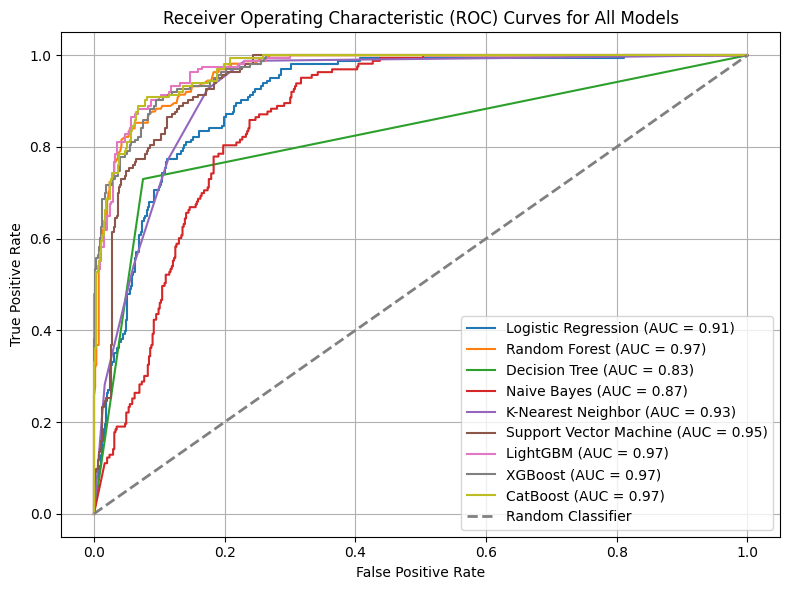

In [10]:
plt.figure(figsize=(8, 6))

for model_name, model in models.items():
    # Make predictions (probabilities) for the positive class
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test_scaled)[:, 1]
    else:
        # For models like SVC without predict_proba by default, if probability=True was set
        # Or, handle cases where probability is not available/relevant differently
        try:
            y_proba = model.decision_function(X_test_scaled)
        except AttributeError:
            print(f"Skipping ROC for {model_name} as it does not support probability predictions.")
            continue

    # Calculate ROC curve and AUC
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)

    # Plot ROC curve
    plt.plot(fpr, tpr, label=f"{model_name} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], linestyle="--", lw=2, color="gray", label="Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC) Curves for All Models")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()